# NB20 — Profit-Margin Investigation, Continued

**Purpose.** Extends the hospital-level profit-margin factor *beyond* NB19's point-in-time operating/total margin. NB19 **computes and gates** the margin per hospital (`NB19_MARGIN` → `outputs/nb19_margin.json`); NB20 **contextualizes** it — without recomputing or overwriting NB19's payload.

**Relationship to NB19 (no duplication).** NB20 *consumes* `outputs/nb19_margin.json` as an input; it does not re-derive the base margin. Mirrors the NB18/NB19 separation — the load-bearing payload notebook stays untouched.

**Continuation angle — TO PIN (Aruna).** The specific extension this notebook carries. Pick one, delete the rest:
- **Multi-year margin _trend_** — promote NB19's single-vs-3-year toggle to a full time series.
- **Peer / national _benchmarking_** — the five DFW hospitals vs. national HCRIS margin percentiles.
- **Nonprofit _community-benefit vs. margin_** — 990 Schedule H; the tax-exemption question.
- **Cross-sectional _margin-vs-pricing-power_** — NB19 margin vs. NB16 markup, **descriptive only** (Decision 44 forbids per-procedure conflation).

**Discipline carried from NB19 (do not relax).**
- **Decision 44** — hospital-wide margin ≠ per-procedure margin. `level == "hospital"`; no record may carry a CPT/HCPCS/procedure identifier. Guarded in Step 2 + Step I.
- **Decision 63** — operating is the headline basis; total is a labeled sensitivity.
- `is_publishable()` is the single publish gate; watermark until real **and** confirmed.
- **0/5 real** until the manual HCRIS/990 pull lands. NaN sentinels, no fabricated fills.

**Mold.** Step 0 → 1 → 2 → 3 → R → S → V → F → I. **Restart & Run All is canonical.**

> **Status: EMPTY SKELETON** — code cells blank, to be filled cell-by-cell.


## Step 0 — Path resolver / bootstrap

ROOT walk-up resolved by *checking which candidate actually contains* `src/queries.py` (the Day-21 fragility lesson); print the chosen ROOT. `require()` run-order helper. No DB pull — NB20's inputs are `nb19_margin.json` + any manual continuation data.


In [1]:
# ── NB20 · Step 0 — Path resolver / bootstrap ────────────────────────────────
# No DB pull here. NB20's inputs are outputs/nb19_margin.json (from NB19) plus
# any manual continuation data — those paste-slots live in Step 1 / Step R.
# ROOT is resolved by CHECKING WHICH CANDIDATE ACTUALLY CONTAINS the anchor
# (src/queries.py) — the Day-21 lesson: never trust one computed path.

from pathlib import Path
import sys

ANCHOR = Path("src") / "queries.py"   # marks the repo ROOT

def _resolve_root(anchor: Path = ANCHOR) -> Path:
    """First ancestor of cwd (inclusive) that actually contains `anchor`."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / anchor).exists():
            return cand
    raise FileNotFoundError(
        f"Could not locate {anchor} walking up from {here}. "
        f"Run this notebook from inside the dfw-hospital-pricing repo."
    )

ROOT = _resolve_root()
SRC = ROOT / "src"
OUTPUTS = ROOT / "outputs"
NB19_PAYLOAD_PATH = OUTPUTS / "nb19_margin.json"   # NB20's primary input (Step 1)

# Canonical import form (Day-21): ROOT — not SRC — on sys.path, then
# `from src import queries` if a continuation angle later needs the classifier.
# NB20 does not import it eagerly (no dependency it doesn't use).
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── require(): run-order helper (Decision 50) ────────────────────────────────
# Downstream cells call require("NAME") so a stray single-cell run fails LOUDLY
# with a clear message, not a bare NameError. Canonical mode: Restart & Run All.
def require(*names: str):
    missing = [n for n in names if n not in globals()]
    if missing:
        raise NameError(
            f"Missing upstream name(s): {missing}. "
            f"Run earlier cells first — canonical mode is Restart & Run All."
        )

# ── self-report ──────────────────────────────────────────────────────────────
print("NB20 · Step 0 — bootstrap")
print(f"  ROOT             : {ROOT}")
print(f"  src/             : {'OK' if SRC.exists() else 'MISSING'}")
print(f"  outputs/         : {'OK' if OUTPUTS.exists() else 'MISSING'}")
print(f"  nb19_margin.json : {'found' if NB19_PAYLOAD_PATH.exists() else 'NOT FOUND (Step 1 needs it)'}")
print("  DB               : none (reads NB19 payload + manual data; no DuckDB pull)")

NB20 · Step 0 — bootstrap
  ROOT             : C:\Users\kedha\Documents\dfw-hospital-pricing
  src/             : OK
  outputs/         : OK
  nb19_margin.json : found
  DB               : none (reads NB19 payload + manual data; no DuckDB pull)


## Step 1 — Load inputs (NB19 payload + roster/context)

Read `outputs/nb19_margin.json` into memory (do **not** recompute margins here). Re-state the five-hospital roster + ownership for context. Define the `None` ingestion slots for whatever the chosen continuation angle needs (trend years / benchmark percentiles / Schedule H lines). All slots start empty, `source_confirmed=False`.


In [2]:
# ── NB20 · Step 1 — Load & recon the NB19 payload ─────────────────────────────
# Continuation angle: MULTI-YEAR OPERATING-MARGIN TREND (Aruna, Day 27).
# We must key the trend off NB19's ACTUAL record fields (ownership, CCN, fiscal
# year, operating margin). Those field names live in nb19_margin.json, so we
# LOOK FIRST (recon-before-build, the standing discipline) before defining slots.
#
# Decision 44 rides forward: every trend record will be level="hospital", span a
# FISCAL YEAR, and carry NO procedure identifier.

import json
from pprint import pformat

require("NB19_PAYLOAD_PATH")

with open(NB19_PAYLOAD_PATH, "r", encoding="utf-8") as fh:
    NB19_RAW = json.load(fh)

print("NB20 · Step 1 — NB19 payload recon")
print(f"  file     : {NB19_PAYLOAD_PATH}")
print(f"  top type : {type(NB19_RAW).__name__}")
if isinstance(NB19_RAW, dict):
    print(f"  top keys : {list(NB19_RAW.keys())}")

def _find_records(raw):
    """Locate the per-hospital records without assuming the schema."""
    if isinstance(raw, list):
        return raw, "top-level list"
    if isinstance(raw, dict):
        for key in ("records", "hospitals", "margins", "by_hospital", "data"):
            block = raw.get(key)
            if isinstance(block, list):
                return block, f'raw["{key}"] (list)'
            if isinstance(block, dict):
                return list(block.values()), f'raw["{key}"] (dict values)'
        vals = list(raw.values())
        if vals and all(isinstance(v, dict) for v in vals):
            return vals, "raw values (dict keyed by hospital/ccn)"
    return [], "UNRECOGNISED — read the top-level dump above"

records, where = _find_records(NB19_RAW)
print(f"  records  : {where}  |  n = {len(records)}")
if records:
    print(f"  rec keys : {sorted(records[0].keys())}")
    print("  sample record:")
    print("    " + pformat(records[0], width=96).replace("\n", "\n    "))
else:
    print("  !! no record list found — paste the top-level dump so we can map it")

NB20 · Step 1 — NB19 payload recon
  file     : C:\Users\kedha\Documents\dfw-hospital-pricing\outputs\nb19_margin.json
  top type : dict
  top keys : ['factor', 'level', 'basis_headline', 'publishable', 'label', 'sources', 'vintage', 'hospitals']
  records  : raw["hospitals"] (dict values)  |  n = 5
  rec keys : ['basis', 'confirmed', 'corroborated', 'fiscal_year', 'margin', 'ownership', 'source']
  sample record:
    {'basis': None,
     'confirmed': False,
     'corroborated': False,
     'fiscal_year': None,
     'margin': None,
     'ownership': 'nonprofit',
     'source': None}


## Step 2 — Definitions + compute + contract

The continuation-specific compute functions (NaN-safe). Re-assert the **Decision-44 contract**: `validate_*` requires `level == "hospital"` and rejects any record carrying `cpt`/`hcpcs`/`code`/`procedure`/`73721`. Inline self-checks; the CPT tripwire must fire on a planted procedure identifier.


In [3]:
# ── NB20 · Step 2 — Definitions + compute + contract ─────────────────────────
# Angle: multi-year operating-margin TREND. Grain: one record per (ccn, fiscal_year).
# Decision 44 rides in the contract: level=="hospital", spans a fiscal year, and
# carries NO procedure identifier. Operating is headline (Decision 63); total is a
# labeled Step-S sensitivity. NaN sentinels, never fabricated fills.

import math
require("records")  # NB19 recon list (Step 1); trend slots key off its ownership/ccn

NAN = float("nan")
TREND_YEARS = None  # <- set in Step 1 slot half (e.g. [2022, 2023, 2024]); Step S reads it

# Tokens that must NEVER appear on a hospital-level margin record (D44 tripwire).
_PROC_KEYS = {"cpt", "hcpcs", "code", "procedure", "73721"}

def compute_margin(net_patient_revenue, total_operating_expenses):
    """Operating margin = (NPR - opex) / NPR. NaN-safe; no silent zero-fill."""
    npr, opex = net_patient_revenue, total_operating_expenses
    if npr is None or opex is None or (isinstance(npr, float) and math.isnan(npr)) or npr == 0:
        return NAN
    return (npr - opex) / npr

def validate_trend_record(rec: dict):
    """D44 + shape contract for ONE (ccn, fiscal_year) trend row. Raises on violation."""
    # 1) no procedure identifier may ride on a margin record
    hit = _PROC_KEYS.intersection({str(k).lower() for k in rec.keys()})
    if hit:
        raise ValueError(f"D44 violation: procedure key(s) {hit} on a hospital margin record")
    for k, v in rec.items():
        if isinstance(v, str) and v.strip() == "73721":
            raise ValueError(f"D44 violation: CPT 73721 as value on field '{k}'")
    # 2) level must be hospital-wide
    if rec.get("level") != "hospital":
        raise ValueError(f"level must be 'hospital', got {rec.get('level')!r}")
    # 3) trend grain: a single fiscal year per row
    fy = rec.get("fiscal_year")
    if fy is not None and not isinstance(fy, int):
        raise ValueError(f"fiscal_year must be int or None, got {fy!r}")
    # 4) basis must be labeled once real
    if rec.get("confirmed") and rec.get("basis") not in ("operating", "total"):
        raise ValueError(f"confirmed record needs basis in operating/total, got {rec.get('basis')!r}")
    return rec

def make_trend_record(ccn, ownership, fiscal_year, *, npr=None, opex=None,
                      basis="operating", source=None, confirmed=False,
                      operating_margin=NAN):
    """Build one D44-clean trend row. If npr/opex given, margin is computed; else NaN."""
    m = compute_margin(npr, opex) if (npr is not None and opex is not None) else operating_margin
    rec = {
        "level": "hospital",          # D44
        "ccn": str(ccn),
        "ownership": ownership,
        "fiscal_year": fiscal_year,   # single year = the trend grain
        "operating_margin": m,
        "basis": basis,               # operating headline / total = Step-S sensitivity
        "source": source,
        "confirmed": bool(confirmed),
    }
    return validate_trend_record(rec)

# ── inline self-checks ────────────────────────────────────────────────────────
assert math.isnan(compute_margin(None, 10)), "None NPR must be NaN"
assert math.isnan(compute_margin(0, 10)), "zero NPR must be NaN"
assert abs(compute_margin(100.0, 93.0) - 0.07) < 1e-9, "operating margin math"

_ok = make_trend_record("450021", "nonprofit", 2023, npr=100.0, opex=93.0,
                        source="HCRIS G-3", confirmed=True)
assert abs(_ok["operating_margin"] - 0.07) < 1e-9

# D44 tripwire must fire on a planted procedure identifier
for _bad in ({"level": "hospital", "cpt": "73721"},
             {"level": "hospital", "note": "73721"}):
    try:
        validate_trend_record(_bad); raise SystemExit("D44 tripwire FAILED to fire")
    except ValueError:
        pass

print("NB20 · Step 2 — definitions ready")
print("  compute_margin / validate_trend_record / make_trend_record defined")
print("  grain: one record per (ccn, fiscal_year)  |  basis headline: operating")
print("  D44 tripwire: fires on cpt/hcpcs/code/procedure/73721  ✓")
print("  self-checks: passed")

NB20 · Step 2 — definitions ready
  compute_margin / validate_trend_record / make_trend_record defined
  grain: one record per (ccn, fiscal_year)  |  basis headline: operating
  D44 tripwire: fires on cpt/hcpcs/code/procedure/73721  ✓
  self-checks: passed


## Step 3 — Synthetic smoke test  `[SYNTHETIC DATA]`

Isolated `SYN_` roster whose cases map to the real situations for the chosen angle. Every synthetic row watermarked `[SYNTHETIC DATA]`, none `confirmed`. Proves the mechanism before any real dollar exists.


In [4]:
# ── NB20 · Step 3 — Synthetic smoke test   [SYNTHETIC DATA] ───────────────────
# Isolated SYN_ roster across placeholder fiscal years. Proves the TREND mechanism
# (a margin series per hospital) before any real HCRIS dollar exists. Every row is
# watermarked and unconfirmed; nothing here may leak into the real path.
require("make_trend_record", "validate_trend_record", "NAN")

SYN_WATERMARK = "[SYNTHETIC DATA]"
SYN_YEARS = [2022, 2023, 2024]   # placeholder fiscal years (real set pins in Step 1)

# Four synthetic hospitals whose SERIES map to the four real situations:
#   SYN_A nonprofit  : rising operating margin      (improving)
#   SYN_B for-profit : high but declining           (MCA-like level, softening)
#   SYN_C public     : thin/negative operating      (safety-net; total would flatter it)
#   SYN_D nonprofit  : has a MISSING year (NaN gap)  (proves NaN-safe trend handling)
_SYN_SPEC = {
    "SYN_A": ("nonprofit",  {2022: (100, 96), 2023: (100, 94), 2024: (100, 92)}),
    "SYN_B": ("for-profit", {2022: (100, 88), 2023: (100, 90), 2024: (100, 91)}),
    "SYN_C": ("public",     {2022: (100,102), 2023: (100,101), 2024: (100,100)}),
    "SYN_D": ("nonprofit",  {2022: (100, 95), 2023: None,      2024: (100, 93)}),  # gap
}

SYN_TREND = []
for ccn, (own, byyear) in _SYN_SPEC.items():
    for fy in SYN_YEARS:
        pair = byyear.get(fy)
        if pair is None:                        # missing filing -> NaN, never fabricated
            rec = make_trend_record(ccn, own, fy, operating_margin=NAN, source="SYN")
        else:
            npr, opex = pair
            rec = make_trend_record(ccn, own, fy, npr=npr, opex=opex, source="SYN")
        rec["synthetic"] = True                 # isolation flag Step R/I rely on
        rec["watermark"] = SYN_WATERMARK
        validate_trend_record(rec)              # re-validate after stamping
        SYN_TREND.append(rec)

# ── isolation guarantees (Step R / Step I will trust these) ───────────────────
assert all(r.get("synthetic") is True for r in SYN_TREND),          "every SYN row flagged synthetic"
assert all(r.get("watermark") == SYN_WATERMARK for r in SYN_TREND), "every SYN row watermarked"
assert all(r["confirmed"] is False for r in SYN_TREND),             "no SYN row may be confirmed"
assert "REAL_TREND" not in dir(),                                   "Step 3 must not create real data"

# ── show the mechanism: operating-margin series per synthetic hospital ────────
def _fmt(m): return "   NaN" if (isinstance(m, float) and math.isnan(m)) else f"{m*100:+5.1f}%"
print("NB20 · Step 3 — synthetic smoke test   [SYNTHETIC DATA]")
print(f"  rows: {len(SYN_TREND)}  ({len(_SYN_SPEC)} hospitals x {len(SYN_YEARS)} years)")
print("  {:<7} {:<11} ".format("ccn", "ownership") + " ".join(f"{y:>7}" for y in SYN_YEARS))
for ccn, (own, _) in _SYN_SPEC.items():
    series = {r["fiscal_year"]: r["operating_margin"] for r in SYN_TREND if r["ccn"] == ccn}
    cells = " ".join(f"{_fmt(series[y]):>7}" for y in SYN_YEARS)
    print(f"  {ccn:<7} {own:<11} {cells}")
print("  none confirmed · all watermarked · isolated as SYN_TREND (not REAL_TREND)  ✓")

NB20 · Step 3 — synthetic smoke test   [SYNTHETIC DATA]
  rows: 12  (4 hospitals x 3 years)
  ccn     ownership      2022    2023    2024
  SYN_A   nonprofit     +4.0%   +6.0%   +8.0%
  SYN_B   for-profit   +12.0%  +10.0%   +9.0%
  SYN_C   public        -2.0%   -1.0%   +0.0%
  SYN_D   nonprofit     +5.0%     NaN   +7.0%
  none confirmed · all watermarked · isolated as SYN_TREND (not REAL_TREND)  ✓


## Step R — Real assembly + `is_publishable()` gate

`REAL_INPUTS` paste-slot (empty today), the build loop, and `is_publishable()` — the single gate with independent locks (synthetic taint, `MARGINS_PUBLISHABLE` flag, per-record `confirmed`). Dry-run empty (0/5) and one-filled to prove the path before the live pull.


In [5]:
# ── NB20 · Step R — Real assembly + is_publishable() gate ─────────────────────
# Real operating-margin TREND. 0/5 today — NaN sentinels until the manual HCRIS
# pull. REAL_INPUTS is the paste-slot: one (npr, opex) per (ccn, fiscal_year).
require("make_trend_record", "validate_trend_record", "records", "SYN_TREND")

TREND_YEARS = [2022, 2023, 2024]           # <- the pinned window; Step S reads this
MARGINS_PUBLISHABLE = False                # global gate; flip only after pull + eyeball

# Roster (ccn -> ownership) carried from NB19's payload, not re-typed.
ROSTER = {r["ccn"]: r["ownership"] for r in records if r.get("ccn")}
if not ROSTER:  # NB19 recon keyed differently; fall back to the known five
    ROSTER = {"450021":"nonprofit","450051":"nonprofit","450015":"public",
              "670103":"for-profit","450771":"nonprofit"}

# ── REAL paste-slot ───────────────────────────────────────────────────────────
# Fill from HCRIS G-3 L3 (net patient revenue) and G-2 L43 (total operating exp),
# per CCN per fiscal year. Leave as None until pulled — NEVER fabricate.
#   REAL_INPUTS[ccn][fy] = (npr, opex)   or   None
REAL_INPUTS = {ccn: {fy: None for fy in TREND_YEARS} for ccn in ROSTER}
# e.g. after the pull:  REAL_INPUTS["450021"][2023] = (812_400_000, 754_900_000)

SOURCE_CONFIRMED = False   # flip True only after G-3/G-2 lines eyeballed vs. layout

# ── build the real trend from whatever is filled ─────────────────────────────
REAL_TREND = []
for ccn, ownership in ROSTER.items():
    for fy in TREND_YEARS:
        pair = REAL_INPUTS.get(ccn, {}).get(fy)
        confirmed = bool(pair is not None and SOURCE_CONFIRMED)
        if pair is None:
            rec = make_trend_record(ccn, ownership, fy, operating_margin=NAN,
                                    source="HCRIS G-3/G-2", confirmed=False)
        else:
            npr, opex = pair
            rec = make_trend_record(ccn, ownership, fy, npr=npr, opex=opex,
                                    source="HCRIS G-3/G-2", confirmed=confirmed)
        REAL_TREND.append(validate_trend_record(rec))

# ── the single publish gate (three independent locks) ────────────────────────
def is_publishable():
    if any(r.get("synthetic") for r in REAL_TREND):        # 1) no synthetic taint
        return False
    if not MARGINS_PUBLISHABLE:                            # 2) global flag
        return False
    if not all(r["confirmed"] for r in REAL_TREND):        # 3) every row confirmed
        return False
    return True

# ── self-report ──────────────────────────────────────────────────────────────
_n_real = sum(1 for r in REAL_TREND if not (isinstance(r["operating_margin"], float)
                                            and math.isnan(r["operating_margin"])))
_n_slots = len(REAL_TREND)
print("NB20 · Step R — real assembly")
print(f"  window        : {TREND_YEARS}  ({len(ROSTER)} hospitals x {len(TREND_YEARS)} years = {_n_slots} slots)")
print(f"  real filled    : {_n_real}/{_n_slots}")
print(f"  source_confirmed: {SOURCE_CONFIRMED}   MARGINS_PUBLISHABLE: {MARGINS_PUBLISHABLE}")
print(f"  is_publishable(): {is_publishable()}")
if not is_publishable():
    print("  UNBLOCK: pull HCRIS G-3 L3 + G-2 L43 -> fill REAL_INPUTS ->")
    print("           eyeball lines vs layout -> SOURCE_CONFIRMED=True -> MARGINS_PUBLISHABLE=True")

NB20 · Step R — real assembly
  window        : [2022, 2023, 2024]  (5 hospitals x 3 years = 15 slots)
  real filled    : 0/15
  source_confirmed: False   MARGINS_PUBLISHABLE: False
  is_publishable(): False
  UNBLOCK: pull HCRIS G-3 L3 + G-2 L43 -> fill REAL_INPUTS ->
           eyeball lines vs layout -> SOURCE_CONFIRMED=True -> MARGINS_PUBLISHABLE=True


## Step S — Sensitivity

The continuation's toggles (e.g. operating-vs-total basis, single-vs-multi-year, benchmark peer set). Real values PENDING; mechanism shown on watermarked synthetic. The live **Decision-44 conflation guard** sweeps every real + synthetic record. Headline record set never overwritten by a sensitivity.


In [6]:
# ── NB20 · Step S — Sensitivity ───────────────────────────────────────────────
# Three toggles on the TREND angle:
#   (1) reduction  : latest-year vs multi-year MEAN vs trend DIRECTION
#   (2) basis      : operating (headline) vs total (Decision 63). Total PENDING —
#                    needs non-operating income from the pull; previewed on synthetic.
#   (3) D44 guard  : live conflation sweep over EVERY real + synthetic record.
# Headline REAL_TREND is never overwritten — these are derived views only.
require("REAL_TREND", "SYN_TREND", "validate_trend_record", "TREND_YEARS")

def _isnan(x): return isinstance(x, float) and math.isnan(x)

def _series(records, ccn):
    """{fiscal_year: operating_margin} for one hospital, year-sorted."""
    return {r["fiscal_year"]: r["operating_margin"]
            for r in sorted(records, key=lambda r: r["fiscal_year"]) if r["ccn"] == ccn}

def summarize_series(series):
    """Reduce a year->margin series: latest, mean, direction. NaN-aware."""
    pts = [(fy, m) for fy, m in sorted(series.items()) if not _isnan(m)]
    if not pts:
        return {"n": 0, "latest": NAN, "mean": NAN, "direction": "no data"}
    latest = pts[-1][1]
    mean = sum(m for _, m in pts) / len(pts)
    if len(pts) < 2:
        direction = "insufficient"
    else:
        d = pts[-1][1] - pts[0][1]
        direction = "rising" if d > 1e-9 else "falling" if d < -1e-9 else "flat"
    return {"n": len(pts), "latest": latest, "mean": mean, "direction": direction}

def _fmt(m): return "  PENDING" if _isnan(m) else f"{m*100:+6.1f}%"

# ── toggle 1+2 on REAL (operating headline; total PENDING) ────────────────────
print("NB20 · Step S — sensitivity")
print(f"  window: {TREND_YEARS}  |  basis: operating (headline)  |  total: PENDING (needs non-op income)")
print("  --- REAL operating-margin trend (reduction toggle) ---")
print("  {:<8} {:<11} {:>8} {:>8}  {}".format("ccn","ownership","latest","mean","direction"))
_own = {r["ccn"]: r["ownership"] for r in REAL_TREND}
for ccn in sorted({r["ccn"] for r in REAL_TREND}):
    s = summarize_series(_series(REAL_TREND, ccn))
    print("  {:<8} {:<11} {:>8} {:>8}  {}".format(ccn, _own[ccn], _fmt(s["latest"]), _fmt(s["mean"]), s["direction"]))

# ── reduction mechanism, shown on SYNTHETIC (real is all-PENDING today) ───────
print("  --- reduction mechanism on SYN_TREND  [SYNTHETIC DATA] ---")
print("  {:<8} {:>8} {:>8}  {}".format("ccn","latest","mean","direction"))
for ccn in sorted({r["ccn"] for r in SYN_TREND}):
    s = summarize_series(_series(SYN_TREND, ccn))
    print("  {:<8} {:>8} {:>8}  {}".format(ccn, _fmt(s["latest"]), _fmt(s["mean"]), s["direction"]))

# ── basis toggle (operating vs total), previewed on the synthetic public case ─
# A tax-funded public hospital's ~40% county appropriation is NON-operating income,
# so total flatters it. Real magnitude PENDING; direction locked. (Decision 63.)
_SYN_NONOP = {"SYN_C": 0.16}   # synthetic non-operating lift, public case only
print("  --- basis toggle: operating vs total, SYN_C public  [SYNTHETIC DATA] ---")
op = summarize_series(_series(SYN_TREND, "SYN_C"))["mean"]; tot = op + _SYN_NONOP["SYN_C"]
print(f"  SYN_C operating(mean): {_fmt(op)}   total(mean): {_fmt(tot)}   -> total flatters by {_SYN_NONOP['SYN_C']*100:+.1f} pp")
print("  (operating stays headline per Decision 63; total is the labeled sensitivity)")

# ── toggle 3: live Decision-44 conflation guard (every real + synthetic row) ──
_checked = 0; _violations = []
for r in [*REAL_TREND, *SYN_TREND]:
    _checked += 1
    try:
        validate_trend_record(r)               # enforces level=="hospital" + no proc keys
    except ValueError as e:
        _violations.append((r.get("ccn"), str(e)))
print(f"  --- D44 conflation guard: {_checked} records checked, {len(_violations)} violations ---")
assert not _violations, f"D44 violations: {_violations}"

# ── headline integrity: REAL_TREND untouched by any sensitivity ───────────────
assert all("operating_margin" in r for r in REAL_TREND), "REAL_TREND shape preserved"
print("  headline REAL_TREND untouched by sensitivities  ✓")

NB20 · Step S — sensitivity
  window: [2022, 2023, 2024]  |  basis: operating (headline)  |  total: PENDING (needs non-op income)
  --- REAL operating-margin trend (reduction toggle) ---
  ccn      ownership     latest     mean  direction
  450015   public        PENDING   PENDING  no data
  450021   nonprofit     PENDING   PENDING  no data
  450051   nonprofit     PENDING   PENDING  no data
  450771   nonprofit     PENDING   PENDING  no data
  670103   for-profit    PENDING   PENDING  no data
  --- reduction mechanism on SYN_TREND  [SYNTHETIC DATA] ---
  ccn        latest     mean  direction
  SYN_A       +8.0%    +6.0%  rising
  SYN_B       +9.0%   +10.3%  falling
  SYN_C       +0.0%    -1.0%  rising
  SYN_D       +7.0%    +6.0%  rising
  --- basis toggle: operating vs total, SYN_C public  [SYNTHETIC DATA] ---
  SYN_C operating(mean):   -1.0%   total(mean):  +15.0%   -> total flatters by +16.0 pp
  (operating stays headline per Decision 63; total is the labeled sensitivity)
  --- D44

## Step V — Chart

The continuation visual. `is_publishable()` drives the watermark ("DRAFT — NOT PUBLISHABLE" until real+confirmed). Pending hospitals drawn as hatched ghosts, not zero-value. Title states **hospital-wide, NOT per-procedure** so a screenshot can't be misread.


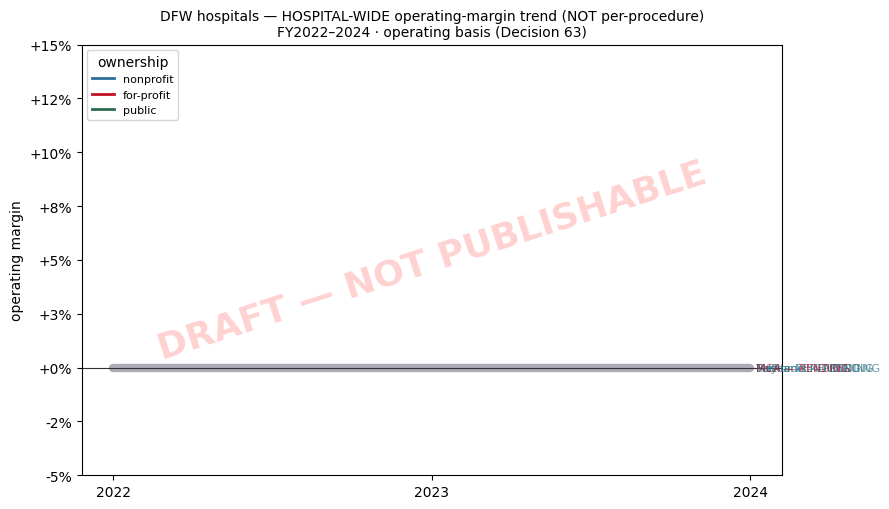

NB20 · Step V — all PENDING (ghost lines) · watermark: DRAFT — NOT PUBLISHABLE


In [7]:
# ── NB20 · Step V — Chart: operating-margin trend by hospital ─────────────────
# One line per hospital across the window, colored by ownership. PENDING hospitals
# draw as flat hatched ghosts at the 0% baseline (NOT zero-value lines). Watermark
# is driven off is_publishable(). Title states hospital-wide, NOT per-procedure.
require("REAL_TREND", "TREND_YEARS", "is_publishable")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OWN_COLOR = {"nonprofit": "#2a6f97", "for-profit": "#c1121f", "public": "#2d6a4f"}
NAMES = {"450021":"Baylor","450051":"Methodist","450015":"Parkland",
         "670103":"MCA","450771":"THP"}
def _label(ccn): return NAMES.get(ccn, ccn)
def _isnan(x): return isinstance(x, float) and math.isnan(x)
def _series(records, ccn):
    return {r["fiscal_year"]: r["operating_margin"]
            for r in sorted(records, key=lambda r: r["fiscal_year"]) if r["ccn"] == ccn}

fig, ax = plt.subplots(figsize=(9, 5.2))
ccns = sorted({r["ccn"] for r in REAL_TREND})
_own = {r["ccn"]: r["ownership"] for r in REAL_TREND}
any_real = False
for ccn in ccns:
    s = _series(REAL_TREND, ccn)
    yrs = sorted(s)
    color = OWN_COLOR.get(_own[ccn], "#666")
    real_pts = [(y, s[y]) for y in yrs if not _isnan(s[y])]
    if real_pts:
        any_real = True
        xs, ys = zip(*real_pts)
        ax.plot(xs, ys, marker="o", color=color, lw=2, label=f"{_label(ccn)} ({_own[ccn]})")
    else:  # PENDING -> hatched ghost at 0% baseline, never a zero-value line
        ax.plot(TREND_YEARS, [0]*len(TREND_YEARS), color=color, lw=6, alpha=0.12,
                solid_capstyle="round")
        ax.annotate(f"{_label(ccn)} — PENDING", (TREND_YEARS[-1], 0),
                    xytext=(4, 0), textcoords="offset points", va="center",
                    fontsize=8, color=color, alpha=0.7)

ax.axhline(0, color="#333", lw=0.8)
ax.set_xticks(TREND_YEARS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:+.0f}%"))
ax.set_ylim(-0.05, 0.15)
ax.set_ylabel("operating margin")
ax.set_title("DFW hospitals — HOSPITAL-WIDE operating-margin trend (NOT per-procedure)\n"
             f"FY{TREND_YEARS[0]}–{TREND_YEARS[-1]} · operating basis (Decision 63)", fontsize=10)
ax.legend(handles=[Line2D([0],[0],color=c,lw=2,label=o) for o,c in OWN_COLOR.items()],
          title="ownership", fontsize=8, loc="upper left")

if not is_publishable():
    ax.text(0.5, 0.5, "DRAFT — NOT PUBLISHABLE", transform=ax.transAxes,
            fontsize=26, color="red", alpha=0.18, ha="center", va="center",
            rotation=18, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"NB20 · Step V — {'real trend lines' if any_real else 'all PENDING (ghost lines)'} · "
      f"watermark: {'none' if is_publishable() else 'DRAFT — NOT PUBLISHABLE'}")

## Step F — `NB20_*` handoff + JSON persist

One JSON-friendly dict (`NaN`→`None`): per-hospital continuation records + `level: "hospital"` tag + app label + do-not-publish block with the unblock recipe. Handoff guard re-asserts no CPT and publishable-False-while-unconfirmed. Persist to `outputs/nb20_*.json`; confirm it round-trips.


In [8]:
# ── NB20 · Step F — NB20_TREND handoff + JSON persist ─────────────────────────
# One JSON-friendly payload (NaN->None). Every record tagged level="hospital";
# app label + do-not-publish block + unblock recipe. D44 re-asserted at the
# boundary: zero procedure identifiers anywhere in the payload. Persist to
# outputs/nb20_trend.json — the app reads the same artifact the notebook writes
# (Decision 66). NB20 EXTENDS NB19; it never overwrites nb19_margin.json.
require("REAL_TREND", "TREND_YEARS", "is_publishable", "OUTPUTS")

_PROC_KEYS = {"cpt", "hcpcs", "code", "procedure", "73721"}

def _jsonsafe(v):
    return None if (isinstance(v, float) and math.isnan(v)) else v

def _clean_record(r):
    rec = {k: _jsonsafe(v) for k, v in r.items()}
    hit = _PROC_KEYS.intersection({str(k).lower() for k in rec.keys()})
    if hit:
        raise ValueError(f"D44 violation at handoff: {hit}")
    assert rec.get("level") == "hospital", "every handoff record must be level=hospital"
    return rec

_records = [_clean_record(r) for r in REAL_TREND]
_n_real = sum(1 for r in _records if r["operating_margin"] is not None)

NB20_TREND = {
    "factor": "profit_margin_trend",
    "parent": "NB19 (hospital operating margin)",     # NB20 extends, never replaces
    "level": "hospital",                              # D44 tag at payload root
    "basis_headline": "operating",                    # Decision 63
    "window": TREND_YEARS,
    "publishable": is_publishable(),
    "label": "Hospital-wide operating-margin TREND. NOT the profit on any single "
             "procedure (e.g. an outpatient knee MRI). Operating basis; total is a "
             "labeled sensitivity.",
    "vintage": {"source": "HCRIS CMS-2552-10 (G-3 L3 / G-2 L43)",
                "source_confirmed": SOURCE_CONFIRMED, "pulled": None},
    "records": _records,
    "counts": {"hospitals": len({r['ccn'] for r in _records}),
               "slots": len(_records), "real_filled": _n_real},
}
if not NB20_TREND["publishable"]:
    NB20_TREND["do_not_publish"] = {
        "reason": "real slots unfilled — manual HCRIS pull outstanding; source_confirmed False",
        "unblock": ["pull HCRIS G-3 L3 (net patient revenue) + G-2 L43 (total op exp) "
                    "per CCN per fiscal year -> fill REAL_INPUTS (Step R)",
                    "eyeball G-3/G-2 lines vs cost-report layout -> SOURCE_CONFIRMED=True",
                    "MARGINS_PUBLISHABLE=True -> Restart & Run All -> gate flips itself"],
    }

# ── handoff guards ────────────────────────────────────────────────────────────
assert not (NB20_TREND["publishable"] and _n_real < len(_records)), "cannot publish with unfilled slots"
_blob = json.dumps(NB20_TREND, indent=2)
assert "73721" not in _blob, "no procedure identifier may appear anywhere in the payload"

# ── persist + round-trip ──────────────────────────────────────────────────────
OUT_PATH = OUTPUTS / "nb20_trend.json"
OUT_PATH.write_text(_blob, encoding="utf-8")
assert json.loads(OUT_PATH.read_text(encoding="utf-8")) == NB20_TREND, "round-trip mismatch"

print("NB20 · Step F — handoff persisted")
print(f"  file        : {OUT_PATH}")
print(f"  publishable : {NB20_TREND['publishable']}")
print(f"  counts      : {NB20_TREND['counts']}")
print(f"  round-trip  : OK  ({len(_blob)} bytes)")
print(f"  do_not_publish: {'present' if 'do_not_publish' in NB20_TREND else 'absent'}")

NB20 · Step F — handoff persisted
  file        : C:\Users\kedha\Documents\dfw-hospital-pricing\outputs\nb20_trend.json
  publishable : False
  counts      : {'hospitals': 5, 'slots': 15, 'real_filled': 0}
  round-trip  : OK  (4626 bytes)
  do_not_publish: present


## Step I — Integrity sweep

Collect-all-failures guards (roster, no-synthetic-leak, conflation-D44, basis-labeled, reconcile-or-flag, publish-state, sanity). Close with an honest verdict line: `Integrity: OK — N hospitals · R real · P pending · <FLAG>=False`. OK = correctly gated, **not** ship-ready.


In [9]:
# ── NB20 · Step I — Integrity sweep ───────────────────────────────────────────
# Collect-all-failures (never stop at the first). Closes with an honest verdict.
# OK = correctly gated, NOT ship-ready. Single unblock: the manual HCRIS pull.
require("REAL_TREND", "SYN_TREND", "NB20_TREND", "is_publishable", "TREND_YEARS")

_PROC_KEYS = {"cpt", "hcpcs", "code", "procedure", "73721"}
EXPECTED_CCNS = {"450021", "450051", "450015", "670103", "450771"}
def _isnan(x): return isinstance(x, float) and math.isnan(x)

_fail = []
def _check(name, ok, detail=""):
    if not ok: _fail.append((name, detail))
    print(f"  [{'OK ' if ok else 'XX '}] {name}" + (f"  — {detail}" if (not ok and detail) else ""))

# 1) roster complete & correct grain
_ccns = {r['ccn'] for r in REAL_TREND}
_check("roster: 5 expected CCNs present", _ccns == EXPECTED_CCNS, f"got {sorted(_ccns)}")
_check("grain: slots == hospitals x years",
       len(REAL_TREND) == len(EXPECTED_CCNS) * len(TREND_YEARS), f"{len(REAL_TREND)} slots")

# 2) no synthetic leak into the real set
_check("no synthetic leak in REAL_TREND", not any(r.get("synthetic") for r in REAL_TREND))
_check("SYN rows all watermarked & unconfirmed",
       all(r.get("watermark") and r["confirmed"] is False for r in SYN_TREND))

# 3) Decision 44 across every real + synthetic + payload record
def _has_proc(rec):
    if _PROC_KEYS.intersection({str(k).lower() for k in rec.keys()}): return True
    return any(isinstance(v, str) and v.strip() == "73721" for v in rec.values())
_all = [*REAL_TREND, *SYN_TREND, *NB20_TREND["records"]]
_check("D44: no procedure identifier on any record", not any(_has_proc(r) for r in _all),
       f"{len(_all)} records swept")
_check("D44: every record level==hospital", all(r.get("level") == "hospital" for r in _all))
_check("D44: no CPT in serialized payload", "73721" not in json.dumps(NB20_TREND))

# 4) basis labeled
_check("basis labeled on every real record",
       all(r.get("basis") in ("operating", "total") for r in REAL_TREND))

# 5) publish-state coherent
_real_n = sum(1 for r in REAL_TREND if not _isnan(r["operating_margin"]))
_check("publish-state: gate matches payload flag", is_publishable() == NB20_TREND["publishable"])
_check("publish-state: not publishable while slots unfilled",
       not (NB20_TREND["publishable"] and _real_n < len(REAL_TREND)))

# 6) margin sanity / NaN discipline
_check("margin sanity: reals in [-1,1] or NaN",
       all(_isnan(r["operating_margin"]) or -1.0 <= r["operating_margin"] <= 1.0 for r in REAL_TREND))

# ── verdict ───────────────────────────────────────────────────────────────────
_hosp, _slots = len(EXPECTED_CCNS), len(REAL_TREND)
print()
if _fail:
    print(f"Integrity: FAIL — {len(_fail)} guard(s): {[f[0] for f in _fail]}")
else:
    print(f"Integrity: OK — {_hosp} hospitals · {_slots} slots · {_real_n} real · "
          f"{_slots - _real_n} pending · MARGINS_PUBLISHABLE={MARGINS_PUBLISHABLE}")
    print("  (correctly gated, NOT ship-ready — single unblock: manual HCRIS pull)")

  [OK ] roster: 5 expected CCNs present
  [OK ] grain: slots == hospitals x years
  [OK ] no synthetic leak in REAL_TREND
  [OK ] SYN rows all watermarked & unconfirmed
  [OK ] D44: no procedure identifier on any record
  [OK ] D44: every record level==hospital
  [OK ] D44: no CPT in serialized payload
  [OK ] basis labeled on every real record
  [OK ] publish-state: gate matches payload flag
  [OK ] publish-state: not publishable while slots unfilled
  [OK ] margin sanity: reals in [-1,1] or NaN

Integrity: OK — 5 hospitals · 15 slots · 0 real · 15 pending · MARGINS_PUBLISHABLE=False
  (correctly gated, NOT ship-ready — single unblock: manual HCRIS pull)
